
### **Olist E-Commerce: Customer Lifetime Value (CLTV) Prediction Framework**

**Business Scenario**
As part of the upcoming quarterly budget allocation, Olist's Marketing Department requires a predictive framework to estimate the future value of the existing customer base. This analysis transitions customer evaluation from a historical, single-transaction perspective to a forward-looking valuation model.

**Objectives**

1. **Data Engineering:** Aggregate relational tables to form a unified transactional dataset and perform robust data cleaning.
2. **Exploratory Data Analysis:** Analyze customer behavior metrics (Recency, Frequency, Monetary Value).
3. **Predictive Modeling:** Estimate CLTV utilizing both probabilistic "Buy 'Til You Die" (BTYD) frameworks (BG/NBD and Gamma-Gamma) and Machine Learning regression models.
4. **Strategic Recommendations:** Synthesize model outputs to identify high-value segments and prioritize candidates for targeted "win-back" campaigns.

---

### **2. Library Imports & Data Aggregation**

To calculate CLTV, we need a customer's unique identity, the timestamps of their orders, and the monetary value/quantity of those orders. This requires joining the `customers`, `orders`, and `order_items` tables.


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from pathlib import Path

data_dir = Path('Brazilian_E-Commerce_Dataset')

customers = pd.read_csv(data_dir / 'olist_customers_dataset.csv')
orders = pd.read_csv(data_dir / 'olist_orders_dataset.csv')
items = pd.read_csv(data_dir / 'olist_order_items_dataset.csv')
payments = pd.read_csv(data_dir / 'olist_order_payments_dataset.csv')

df = pd.merge(orders, customers, on='customer_id', how='inner')
df = pd.merge(df, items, on='order_id', how='inner')
df = pd.merge(df, payments, on='order_id', how='inner')

df.info()
df.head(5)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117601 entries, 0 to 117600
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117601 non-null  object 
 1   customer_id                    117601 non-null  object 
 2   order_status                   117601 non-null  object 
 3   order_purchase_timestamp       117601 non-null  object 
 4   order_approved_at              117586 non-null  object 
 5   order_delivered_carrier_date   116356 non-null  object 
 6   order_delivered_customer_date  115034 non-null  object 
 7   order_estimated_delivery_date  117601 non-null  object 
 8   customer_unique_id             117601 non-null  object 
 9   customer_zip_code_prefix       117601 non-null  int64  
 10  customer_city                  117601 non-null  object 
 11  customer_state                 117601 non-null  object 
 12  order_item_id                 

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1,credit_card,3,179.12


### Estimating Customer Lifetime Value (CLTV)

Our primary objective is to estimate Customer Lifetime Value (CLTV), the conceptual intersection of corporate finance and marketing strategy. Historically, organizations focused primarily on acquisition costs—asking, "How much capital is required to acquire a new customer?" The CLTV paradigm shifts this focus toward long-term profitability, evaluating the total economic value a customer will generate throughout their entire relationship with the company.

To accurately predict this future value, we rely on foundational behavioral signals. The canonical feature triad used for this prediction is **RFM** (Recency, Frequency, and Monetary value). These metrics are computationally straightforward yet remarkably predictive:

* **Recency (R) — *How recently did the customer transact?***
Recency serves as the strongest indicator of future activity. A dormant customer is highly likely to churn, making the time since their last purchase a critical signal of their active status.
* **Frequency (F) — *How many times has the customer purchased?***
Frequency measures the depth of customer engagement. It signals established loyalty and habit formation that extends beyond a single transactional interaction.
* **Monetary Value (M) — *How much has the customer spent?***
Monetary value quantifies the customer's historical economic contribution, serving as the baseline anchor for predicting expected future spend.

### Data Audit & Quality: Establishing Ground Truth

Before we can accurately predict a customer's future value, we must ensure our historical data represents genuine, revenue-generating behavior. A predictive model is only as good as the signal it receives, so our first step is to interrogate the dataset and clean up any inconsistencies that violate our business logic.

We will apply a strict three-step auditing strategy:

**1. Removing Orphaned Transactions (Missing Customer IDs)**
* **The Context:** CLTV fundamentally relies on tracking an individual's purchasing journey over time. 
* **The Action:** If a transaction lacks a `customer_unique_id`, we cannot link it to a specific person or calculate their purchasing frequency. These rows must be dropped.

**2. Handling System Duplicates**
* **The Context:** Perfectly identical rows in transactional databases are almost always logging errors or accidental double-submissions at checkout, not simultaneous identical purchases.
* **The Action:** We will drop exact duplicates to prevent artificially inflating our Frequency (F) and Monetary (M) signals.

**3. Filtering Economic Anomalies**
* **The Context:** Items with a price of zero (or lower, if present) typically represent bad-debt adjustments, incorrectly applied discounts, or system errors. 
* **The Action:** Since our objective is to model expected *positive revenue*, we will filter the dataset to strictly include valid purchases where the `price` is greater than zero.

In [52]:
df = df.dropna(subset=['customer_unique_id'])
df = df.drop_duplicates()
df = df[df['price'] > 0]

### Categorical Inspection: Unique Values & Value Counts

We will check unique values in order to find **categorical anomalies**. 


In [53]:
status_counts = df['order_status'].value_counts(dropna=False)
print("Order Statuses:\n", status_counts)

print("\n" + "-"*30 + "\n")

payment_counts = df['payment_type'].value_counts(dropna=False)
print("Payment Types:\n", payment_counts)

Order Statuses:
 order_status
delivered      115035
shipped          1244
canceled          566
processing        375
invoiced          371
unavailable         7
approved            3
Name: count, dtype: int64

------------------------------

Payment Types:
 payment_type
credit_card    86769
boleto         22867
voucher         6274
debit_card      1691
Name: count, dtype: int64


### Categorical Data Audit: Validating Revenue Streams

After cleaning our numerical anomalies, we must ensure our categorical data logically supports a predictive financial model. Customer Lifetime Value (CLTV) relies strictly on realized revenue. Therefore, we must inspect the categorical status of our transactions. 

Specifically, we need to verify:
1. **Order Status:** We must identify and exclude incomplete transactions (e.g., `canceled`, `unavailable`, or `processing`). Only `delivered` orders represent actual, realized value.
2. **Payment Types:** We must check for system errors or placeholder values (such as `not_defined`) that could invalidate the financial tracking of the order.

Below, we inspect these distributions and filter the dataset to isolate genuine, completed purchases.

In [54]:
# 1. Inspect the categorical distributions
print("--- Order Status Distribution ---")
print(df['order_status'].value_counts(dropna=False))

print("\n--- Payment Type Distribution ---")
print(df['payment_type'].value_counts(dropna=False))

# 2. Apply strict business logic filters for CLTV

# Keep strictly fully realized (delivered) orders
df = df[df['order_status'] == 'delivered']

# Remove invalid payment placeholders (if any exist in the dataset)
df = df[df['payment_type'] != 'not_defined']

print(f"\nFinal cleaned dataset shape ready for RFM modeling: {df.shape}")

--- Order Status Distribution ---
order_status
delivered      115035
shipped          1244
canceled          566
processing        375
invoiced          371
unavailable         7
approved            3
Name: count, dtype: int64

--- Payment Type Distribution ---
payment_type
credit_card    86769
boleto         22867
voucher         6274
debit_card      1691
Name: count, dtype: int64

Final cleaned dataset shape ready for RFM modeling: (115035, 22)


### Methodological Justification: Defining the Revenue Baseline

When establishing the foundational dataset for Customer Lifetime Value (CLTV) modeling, a critical distinction must be made between a customer's *intent to buy* and *realized revenue*. To ensure the integrity of the predictive framework, we must define a strict boundary for valid transactions.

#### The Ideal Framework vs. Data Constraints
In an ideal financial modeling scenario, an order should only be recognized as realized revenue once the contract of sale is completely irrevocable. This implies two conditions:
1. The product has been successfully fulfilled and is in the possession of the customer.
2. The legal timeframe for returns, cancellations, or refund policies has entirely elapsed (often referred to as the transaction's *maturation period*). 

Transactions that fall within the active return window represent an outstanding financial liability, as they carry a risk of reversal that would artificially inflate our Recency, Frequency, and Monetary (RFM) signals.

#### Our Executive Approach
Because the dataset does not explicitly provide granular granular tracking of individual refund eligibility windows or post-delivery return logs, we must optimize for maximum certainty. 

Therefore, we apply the following business rules:
* **Exclusion of Canceled and Pending States:** Statuses such as `canceled`, `unavailable`, `processing`, and `shipped` are omitted. Including these would introduce structural noise, leading the BG/NBD and Gamma-Gamma models to overestimate customer engagement and future spend based on unfulfilled or failed transactions.
* **Strict Reliance on `delivered` Status:** By filtering the dataset to strictly contain `delivered` orders, we isolate the highest possible level of transactional certainty available to us. This ensures that our calibration baseline is anchored entirely on verified, completed transactions where the product has successfully reached the consumer.

In [55]:
status_counts = df['order_status'].value_counts(dropna=False)
print("Order Statuses:\n", status_counts)

print("\n" + "-"*30 + "\n")





Order Statuses:
 order_status
delivered    115035
Name: count, dtype: int64

------------------------------



### data transformation: credit card type and datetime



In [56]:
df['payment_type'] = df['payment_type'].replace({
    'credit_card': 'card',
    'debit_card': 'card'
})

payment_counts = df['payment_type'].value_counts(dropna=False)
print("Payment Types:\n", payment_counts)

Payment Types:
 payment_type
card       86550
boleto     22362
voucher     6123
Name: count, dtype: int64


In [57]:
#Cast the timestamp to a true datetime object

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# 2. Verify the fix
print("Data type after conversion:", df['order_purchase_timestamp'].dtype)

# 3. Find the timeline boundaries to plan our Holdout period
max_date = df['order_purchase_timestamp'].max()
min_date = df['order_purchase_timestamp'].min()

print(f"\nDataset Timeline:")
print(f"First purchase: {min_date}")
print(f"Last purchase: {max_date}")

Data type after conversion: datetime64[ns]

Dataset Timeline:
First purchase: 2016-10-03 09:44:50
Last purchase: 2018-08-29 15:00:37


### Data Transformation, Type Casting, & Outlier Detection

Now that our transactional data has been filtered logically, we must transition to structural data formatting and statistical quality control. This phase focuses on type casting and managing distribution outliers:

**1. Temporal Type Casting (Datetime Formatting)**
* **The Context:** Our raw dataset imports vital temporal features like `order_purchase_timestamp` as general text strings (`object` data type). 
* **The Action:** For probabilistic modeling (BG/NBD), time deltas are critical. We must explicitly cast our timestamp variables into true `datetime64[ns]` formats so pandas can perform chronological math (e.g., calculating customer tenure and recency).

**2. Statistical Outlier Management**
* **The Context:** E-commerce data frequently contains extreme outliers—either from legitimate high-volume wholesale buyers or data-entry anomalies. While models can handle standard variance, extreme values severely warp both the Gamma-Gamma monetary estimations and machine learning regression algorithms.
* **The Action:** We will evaluate the statistical boundaries of our core continuous variables (`price`, `freight_value`, and `payment_value`). To preserve the integrity of our predictive frameworks without destroying meaningful data, we will apply an upper-bound cap at the 99th percentile to clamp extreme, unrepresentative spikes.

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 115035 entries, 0 to 117600
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       115035 non-null  object        
 1   customer_id                    115035 non-null  object        
 2   order_status                   115035 non-null  object        
 3   order_purchase_timestamp       115035 non-null  datetime64[ns]
 4   order_approved_at              115020 non-null  object        
 5   order_delivered_carrier_date   115033 non-null  object        
 6   order_delivered_customer_date  115027 non-null  object        
 7   order_estimated_delivery_date  115035 non-null  object        
 8   customer_unique_id             115035 non-null  object        
 9   customer_zip_code_prefix       115035 non-null  int64         
 10  customer_city                  115035 non-null  object        
 11  custo

### Data Transformation: Aggregating from Item-Level to Order-Level

The raw Olist dataset is structured at the *item-level*, meaning a single checkout containing multiple items generates multiple rows. However, our objective requires us to analyze customer behavior based on *order values and quantities*. 

To fulfill this requirement, we must perform an aggregation to compress the dataset into a true *order-level* architecture:
1. **Quantity:** We will calculate the total number of items in the cart by extracting the maximum `order_item_id` per `order_id`.
2. **Total Order Value:** We will sum the `price` of all items within the same `order_id` to calculate the true basket value.

Once aggregated, we can accurately identify and manage extreme outliers in basket sizes (quantities) and total values before moving into our RFM modeling.

In [59]:
# Aggregate to one row per order. The orders / items / payments tables join many-to-many
# (an order has several items AND can carry several payment records), so summing price over
# the joined rows would multiply the basket value by the number of payment records, and
# taking the first payment_value would miss split payments. We therefore aggregate items and
# payments separately from their distinct keys and merge the two order-level tables.

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Items -> order level (one row per distinct order_item_id)
items_lv = (df.drop_duplicates(subset=['order_id', 'order_item_id'])
              .groupby('order_id')
              .agg(total_order_price=('price', 'sum'),     # true basket value
                   quantity=('order_item_id', 'max'),      # number of line items
                   freight_value=('freight_value', 'sum')) # total order freight
              .reset_index())

# Payments -> order level (one row per distinct payment_sequential)
pay_lv = (df.drop_duplicates(subset=['order_id', 'payment_sequential'])
            .groupby('order_id')
            .agg(payment_value=('payment_value', 'sum'),          # true total paid
                 payment_installments=('payment_installments', 'max'))
            .reset_index())

# One row of contextual data per order
meta_lv = (df.groupby('order_id')
             .agg(customer_unique_id=('customer_unique_id', 'first'),
                  order_purchase_timestamp=('order_purchase_timestamp', 'first'),
                  payment_type=('payment_type', 'first'),
                  customer_state=('customer_state', 'first'))
             .reset_index())

df = meta_lv.merge(items_lv, on='order_id').merge(pay_lv, on='order_id')
print(f"Order-level rows after aggregation: {len(df)}")
df.head()


Order-level rows after aggregation: 96477


,order_id,customer_unique_id,order_purchase_timestamp,payment_type,customer_state,total_order_price,quantity,freight_value,payment_value,payment_installments
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,2017-09-13 08:59:02,card,RJ,58.90,1,13.29,72.19,2
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,2017-04-26 10:53:06,card,SP,239.90,1,19.93,259.83,3
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,2018-01-14 14:33:31,card,MG,199.00,1,17.87,216.87,5
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,2018-08-08 10:00:35,card,SP,12.99,1,12.79,25.78,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,2017-02-04 13:57:51,card,SP,199.90,1,18.14,218.04,3


### Feature Selection: Dimensionality Reduction & Strategic Isolation

Our objective requires two distinct modeling approaches (Probabilistic BTYD and Machine Learning Regression), which have conflicting data appetites. To satisfy both without cluttering our memory or introducing noise, we will isolate a core subset of features from our raw dataset and discard the rest.

#### 1. The Core RFM Drivers (Kept for Both Tracks)
The BG/NBD and Gamma-Gamma models are mathematical purists. They require only the strict dimensions of a transaction. We keep:
* `customer_unique_id`: The true, persistent identifier of the individual (our "Who").
* `order_purchase_timestamp`: The exact anchor for calculating Recency and Tenure (our "When").
* `price` & `payment_value`: The realized economic value of the basket (our "How Much").

#### 2. The Behavioral Indicators (Kept for Machine Learning)
Unlike probabilistic models, regression algorithms (like XGBoost or Random Forest) thrive on contextual data. We retain specific columns because they are proven behavioral indicators of purchasing power and retention:
* `payment_type` & `payment_installments`: Reliance on credit, cash, or installments heavily influences future lifetime value.
* `freight_value`: Shipping costs act as a primary friction point for e-commerce retention.
* `customer_state`: Captures regional macroeconomic differences in purchasing power across Brazil.


#### 3. The Discarded Noise (Dropped)
To prevent overfitting, we aggressively drop columns that do not serve long-term behavioral prediction:
* **Temporary IDs:** `customer_id` is a temporary session token, not a persistent user ID. 
* **Logistics Artifacts:** Timestamps like `order_delivered_carrier_date` track operational warehouse efficiency, not consumer desire.
* **High-Cardinality Identifiers:** `product_id`, `seller_id`, and `customer_zip_code_prefix` contain too many unique string values, which would fracture our machine learning models without adding proportional predictive value.


In [60]:
# Final order-level feature set. payment_type is retained as a behavioural feature for the
# machine-learning model; high-cardinality identifiers are dropped to avoid fracturing it.
features_to_keep = [
    'customer_unique_id', 'order_purchase_timestamp', 'total_order_price',
    'quantity', 'payment_value', 'freight_value', 'payment_installments',
    'payment_type', 'customer_state'
]

df = df[features_to_keep]

print(f"Final aggregated order-level rows: {len(df)}")
print(f"Columns kept: {list(df.columns)}")
print("-" * 50)
df.info()


Final aggregated order-level rows: 96477
Columns kept: ['customer_unique_id', 'order_purchase_timestamp', 'total_order_price', 'quantity', 'payment_value', 'freight_value', 'payment_installments', 'payment_type', 'customer_state']
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96477 entries, 0 to 96476
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_unique_id        96477 non-null  object        
 1   order_purchase_timestamp  96477 non-null  datetime64[ns]
 2   total_order_price         96477 non-null  float64       
 3   quantity                  96477 non-null  int64         
 4   payment_value             96477 non-null  float64       
 5   freight_value             96477 non-null  float64       
 6   payment_installments      96477 non-null  int64         
 7   payment_type              96477 non-null  objec

### Strategic Decision: Defining the Monetary Metric for CLTV

When establishing the *Monetary* (M) baseline for Customer Lifetime Value modeling, a critical methodological divergence emerges. The Olist dataset distinctly separates the net cost of the goods (`price`) from the logistics cost (`freight_value`) and the final charged amount (`payment_value`). 

Deciding which configuration truly represents "customer value" requires analyzing two opposing business philosophies:

#### 1. The Consumer Perspective (Share of Wallet & Willingness to Pay)
From a behavioral psychology standpoint, the consumer makes no distinction between the cost of the item and the cost of shipping: the total cash outflow from their bank account represents their actual economic friction and commitment to the purchase. 
* **The Rationale:** Utilizing the gross `payment_value` allows us to map the user's exact *Willingness to Pay* and overall *Share of Wallet*. Furthermore, if a customer utilizes financing (installments) or loyalty vouchers, `payment_value` captures the true transactional reality. If Marketing's objective is to identify high-spending VIPs and measure their propensity to allocate budget to our platform, this gross behavioral metric is the strongest indicator.

#### 2. The Financial Perspective (Net Revenue & Unit Economics)
Conversely, from a strict accounting and corporate treasury perspective, revenue generated from shipping (`freight_value`) is a *pass-through cost*—it does not remain with the company but is immediately transferred to logistics partners.
* **The Rationale:** If the primary goal of this predictive model is future budget allocation, we must rely exclusively on the net `price`. Calculating Lifetime Value by including shipping costs or ignoring voucher deficits artificially inflates the financial value of the customer base. This overestimation is dangerous: it can lead the Marketing team to overspend on Customer Acquisition Costs (skewing the LTV:CAC ratio) based on phantom profit margins.

**Executive Conclusion:** Both metrics offer valid signals, but they answer fundamentally different business questions (Behavioral Loyalty vs. Financial Profitability).

**Executive Conclusion:** Both metrics offer valid signals, but they answer fundamentally different business questions. Because the primary objective of this model is to support the Marketing Department's future **budget allocation**, we must prioritize strict financial profitability over gross behavioral metrics. Therefore, we will proceed using the net **`price`** as our Monetary (M) baseline. This ensures that our predictive Lifetime Value represents true net revenue, protecting the business from overestimating customer value based on pass-through logistics costs.

## Managing Outliers and Extreme Values

Before altering the data, we visually inspect the distribution of our newly aggregated continuous numeric features (`total_order_price`, `quantity`, `payment_value`, `freight_value`, `payment_installments`). By plotting both Histograms and Boxplots, we can confirm the presence of heavy right-tail outliers (e.g., massive B2B wholesale orders) that justify our statistical capping strategy.

While we could apply the standard 3x IQR rule for outlier detection, e-commerce data naturally contains highly skewed, valid transactions (such as large B2B wholesale orders). 

Therefore, rather than dropping these records, we will opt to cap our continuous variables at the 99th percentile. This approach mitigates the disruptive impact of extreme anomalies on our predictive models while preserving the integrity of our high-value customer data.





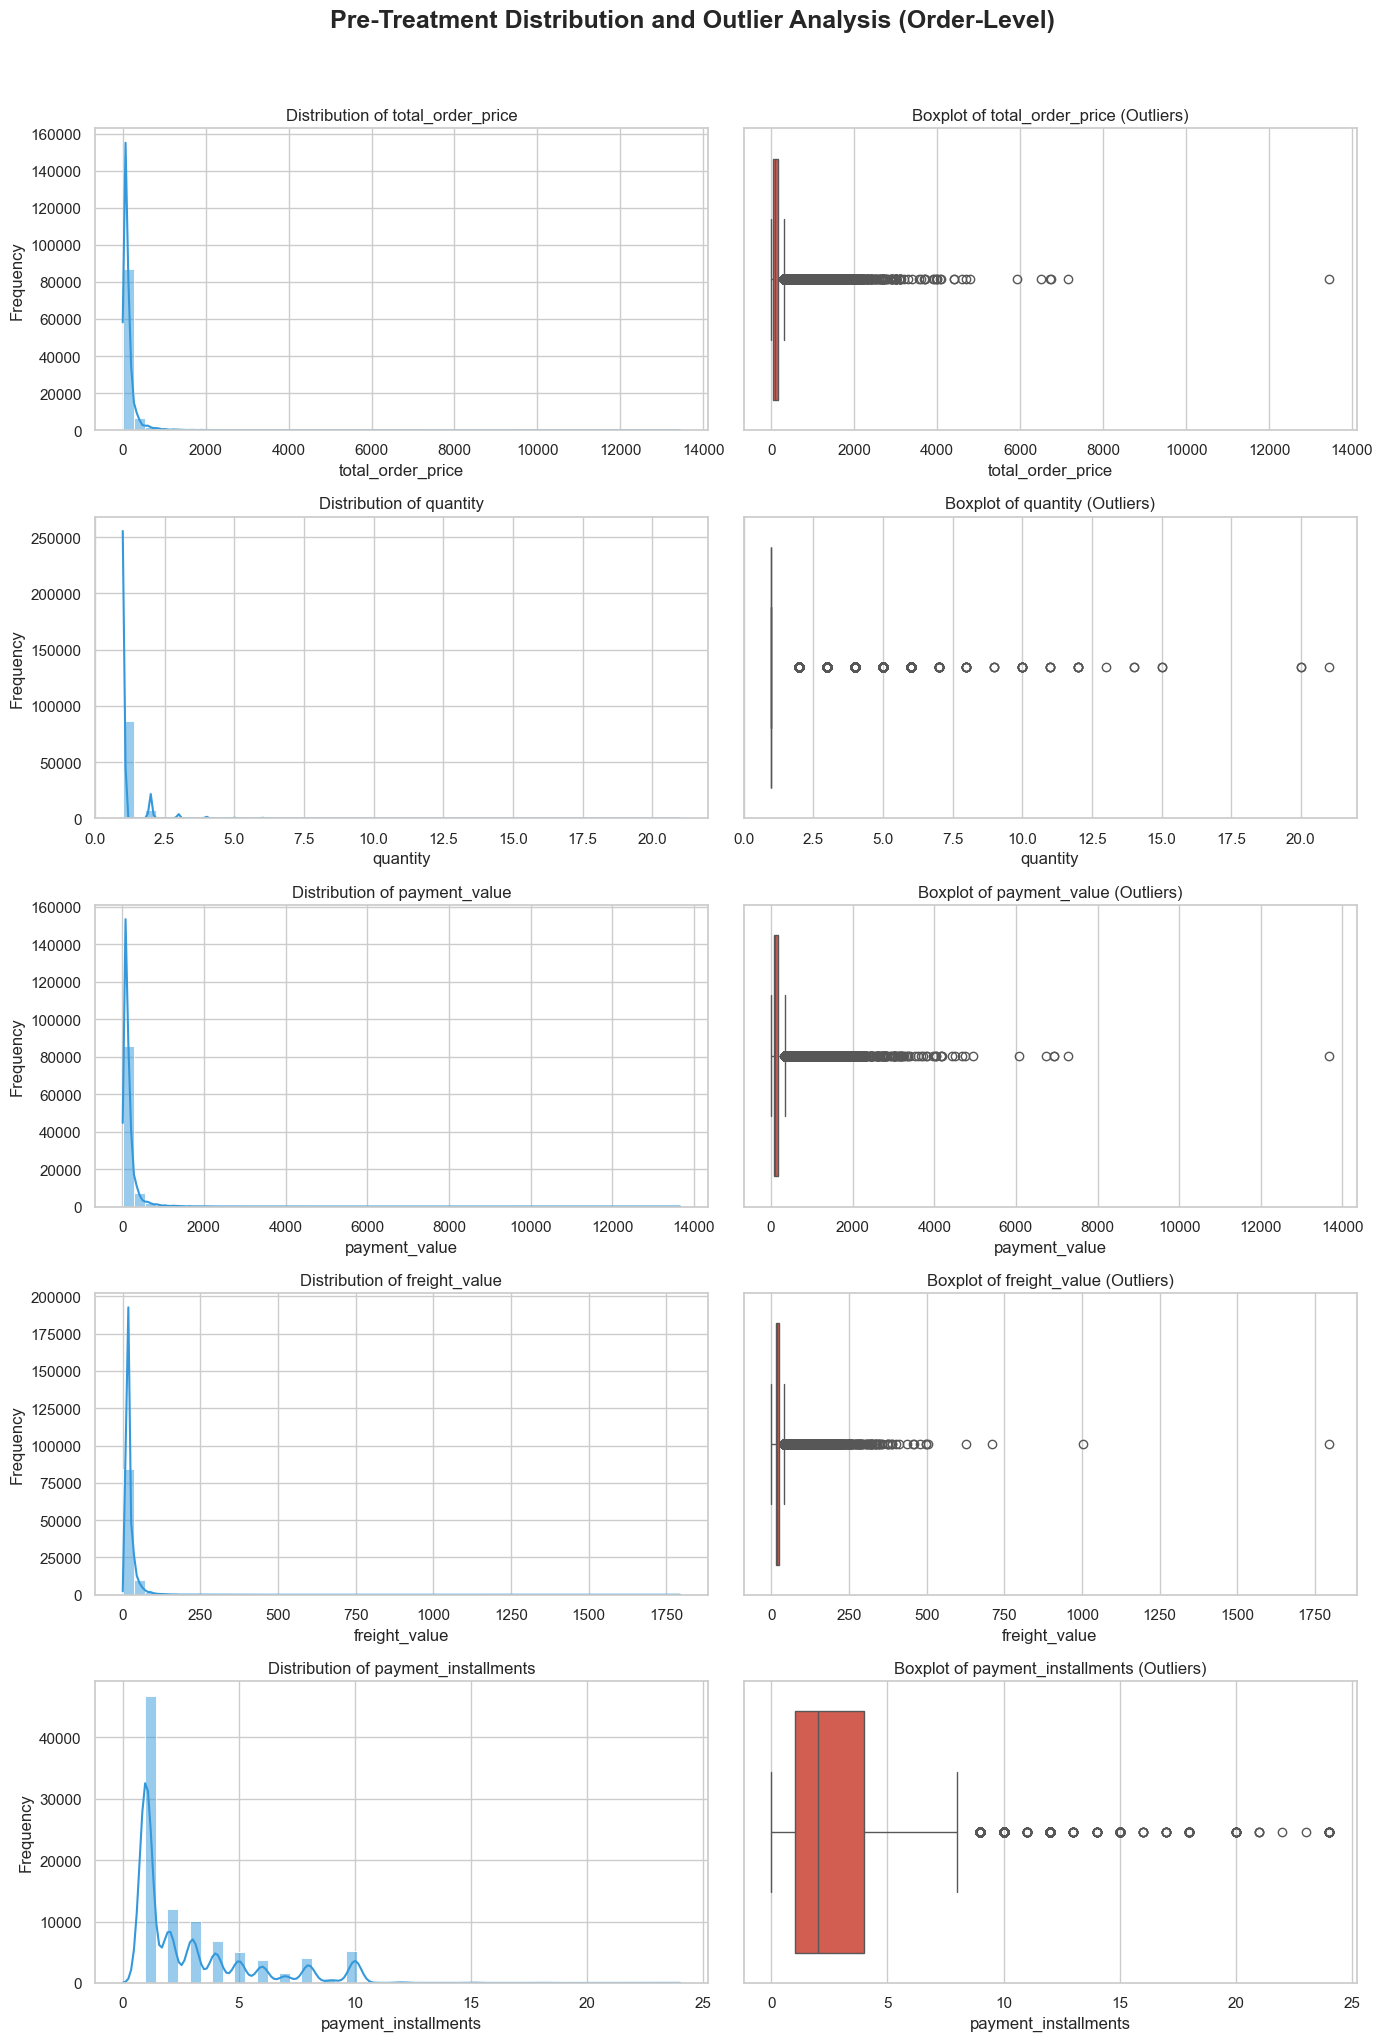

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define our continuous numeric columns
numeric_cols = ['total_order_price', 'quantity', 'payment_value', 'freight_value', 'payment_installments']

# Set up the visual grid
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(14, 20))
fig.suptitle('Pre-Treatment Distribution and Outlier Analysis (Order-Level)', fontsize=18, fontweight='bold', y=1.02)

for i, col in enumerate(numeric_cols):
    # Plot 1: Histogram
    sns.histplot(df[col], bins=50, kde=True, color='#3498db', ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribution of {col}', fontsize=12)
    axes[i, 0].set_ylabel('Frequency')
    
    # Plot 2: Boxplot
    sns.boxplot(x=df[col], color='#e74c3c', ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {col} (Outliers)', fontsize=12)

plt.tight_layout()
plt.show()

### Outlier Strategy: Rejecting IQR in Favor of Percentile Capping (99th Percentile Cap)


The visual diagnostic above reveals a severe right-skewed "long tail" across all continuous financial metrics. The Interquartile Range (IQR) for these features is highly compressed near zero. 

If we were to apply a standard $3 \times \text{IQR}$ threshold, the cutoff point would be exceedingly low. In an e-commerce context, this would result in the unjustified alteration of valid, high-value wholesale or VIP transactions, fundamentally distorting the financial reality of the company's revenue streams.

Instead, we will implement an upper-bound cap at the **99th percentile**. This strategy preserves the economic weight of our top-tier buyers while mitigating the algorithmic disruption caused by the most extreme, single-instance anomalies at the very edge of the tail.


In [62]:
print("--- Applying 99th Percentile Cap to Order-Level Data ---")

# Loop through and mathematically clip the extreme high values
for col in numeric_cols:
    upper_limit = df[col].quantile(0.99)
    print(f"{col}: Cap set at {upper_limit:.2f}")
    df[col] = df[col].clip(upper=upper_limit)

# Verify the new clean maximums
print("\n--- Outlier Management Complete ---")
display(df[numeric_cols].describe().loc[['max']])

--- Applying 99th Percentile Cap to Order-Level Data ---
total_order_price: Cap set at 990.00
quantity: Cap set at 3.00
payment_value: Cap set at 1052.39
freight_value: Cap set at 104.24
payment_installments: Cap set at 10.00

--- Outlier Management Complete ---


,total_order_price,quantity,payment_value,freight_value,payment_installments
max,990.0,3.0,1052.3912,104.2448,10.0


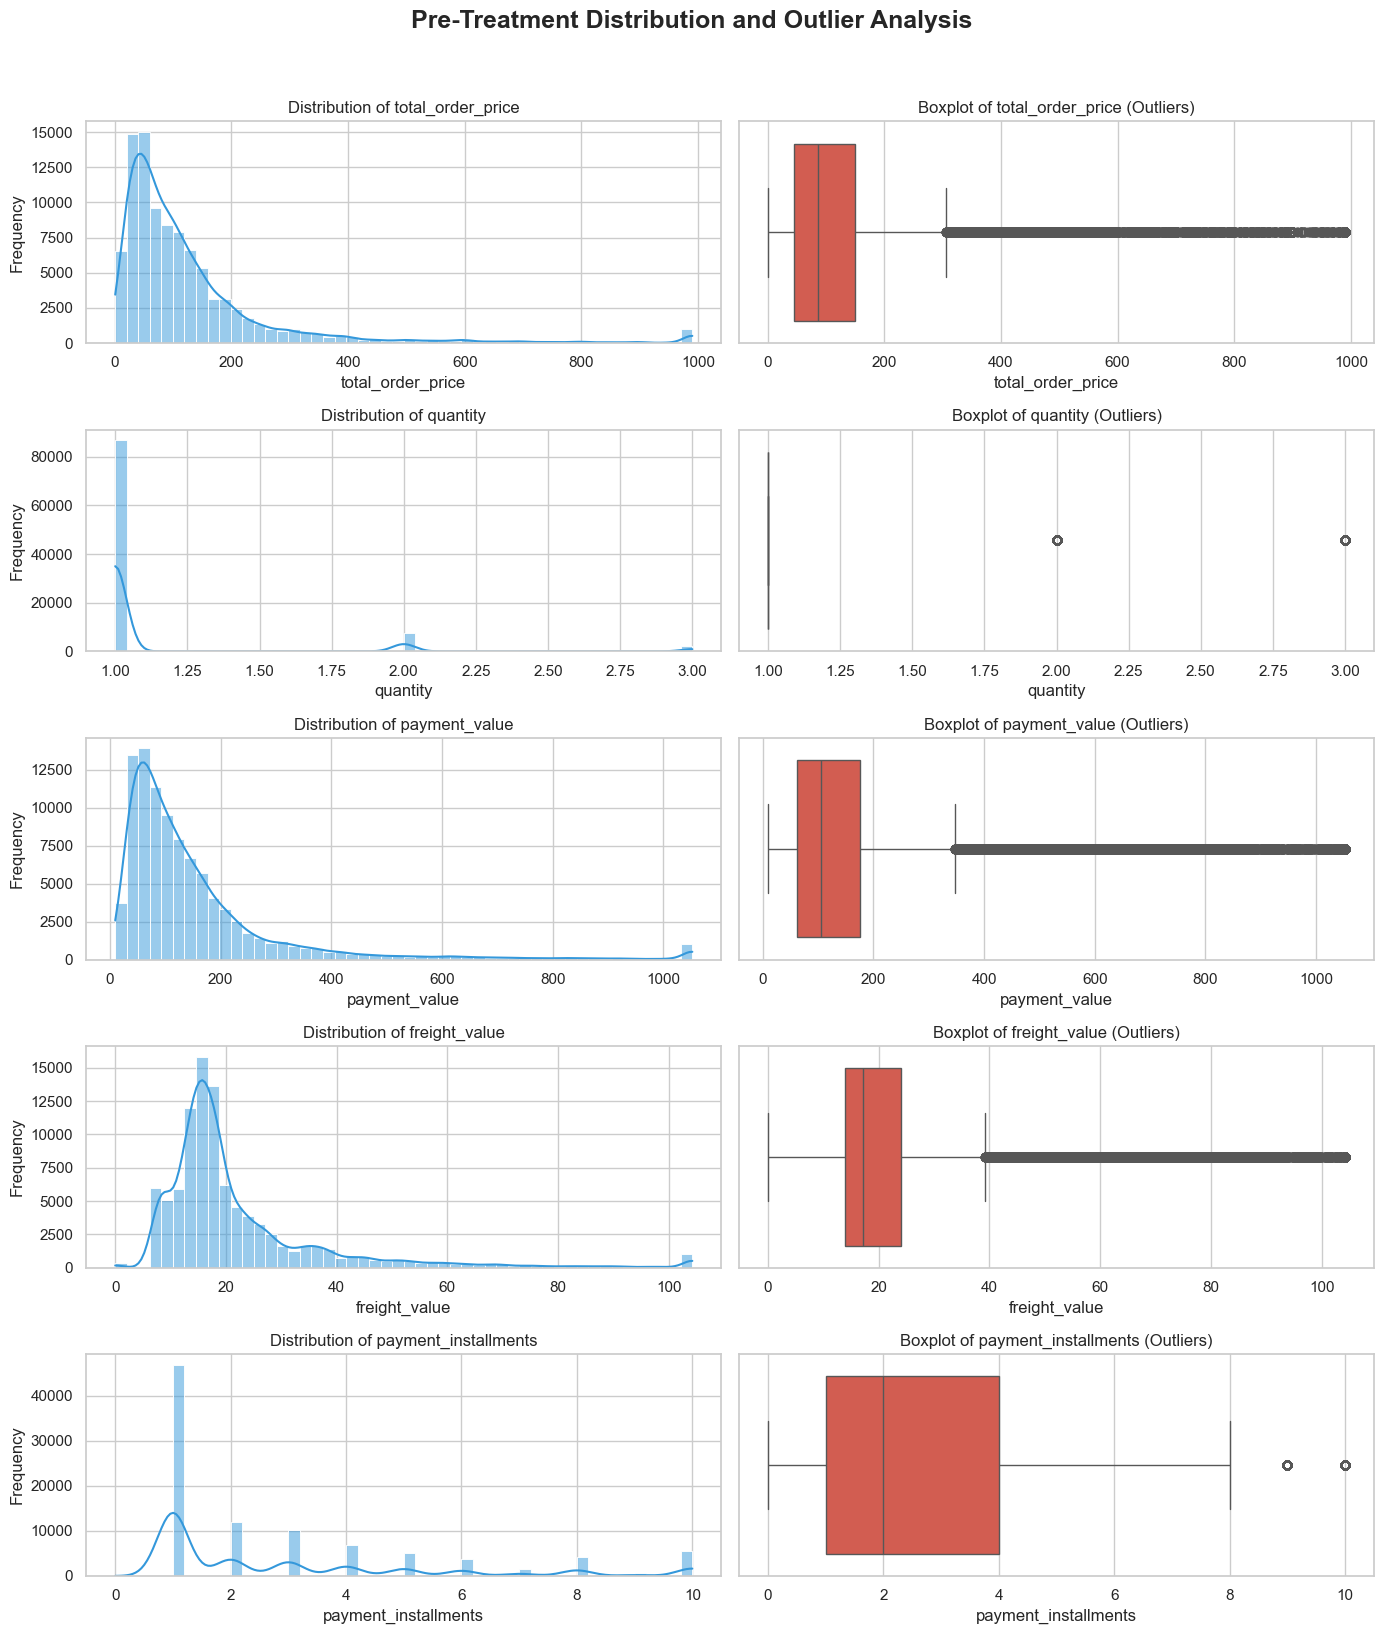

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns


# Set the visual style for a clean, academic look
sns.set_theme(style="whitegrid")

# Create a figure with 4 rows (one for each feature) and 2 columns (Histogram + Boxplot)
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(14, 16))
fig.suptitle('Pre-Treatment Distribution and Outlier Analysis', fontsize=18, fontweight='bold', y=1.02)

for i, col in enumerate(numeric_cols):
    # Plot 1: Histogram (Distribution)
    sns.histplot(df[col], bins=50, kde=True, color='#3498db', ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribution of {col}', fontsize=12)
    axes[i, 0].set_ylabel('Frequency')
    
    # Plot 2: Boxplot (Outlier Detection)
    sns.boxplot(x=df[col], color='#e74c3c', ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {col} (Outliers)', fontsize=12)

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()

# Task B: Exploratory Data Analysis (EDA)
Visualize the distribution of purchase frequency, recency, and customer spend. Highlight insights regarding customer retention.

###  Task B: Exploratory Data Analysis (EDA) - RFM Generation & Customer Behavior EDA

With our dataset aggregated and statistically sound, we transition from transactional data to customer-centric data. Using the `lifetimes` library, we engineer the foundational elements of Customer Lifetime Value: Recency, Frequency, and Monetary Value (using our aggregated `total_order_price`). 

Finally, we plot these distributions to uncover baseline retention insights required for the Marketing Department's budget strategy.

In [64]:
from lifetimes.utils import summary_data_from_transaction_data

# 1. Establish the chronological boundary
snapshot_date = df['order_purchase_timestamp'].max()

# 2. Generate the RFM Matrix
rfm = summary_data_from_transaction_data(
    transactions=df,
    customer_id_col='customer_unique_id',
    datetime_col='order_purchase_timestamp',
    monetary_value_col='total_order_price', 
    observation_period_end=snapshot_date
)



In [65]:
rfm.head()

,frequency,recency,T,monetary_value
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,0.0,0.0,111.0,0.0
0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,0.0,114.0,0.0
0000f46a3911fa3c0805444483337064,0.0,0.0,537.0,0.0
0000f6ccb0745a6a4b88665a16c9f078,0.0,0.0,321.0,0.0
0004aac84e0df4da2b147fca70cf8255,0.0,0.0,288.0,0.0


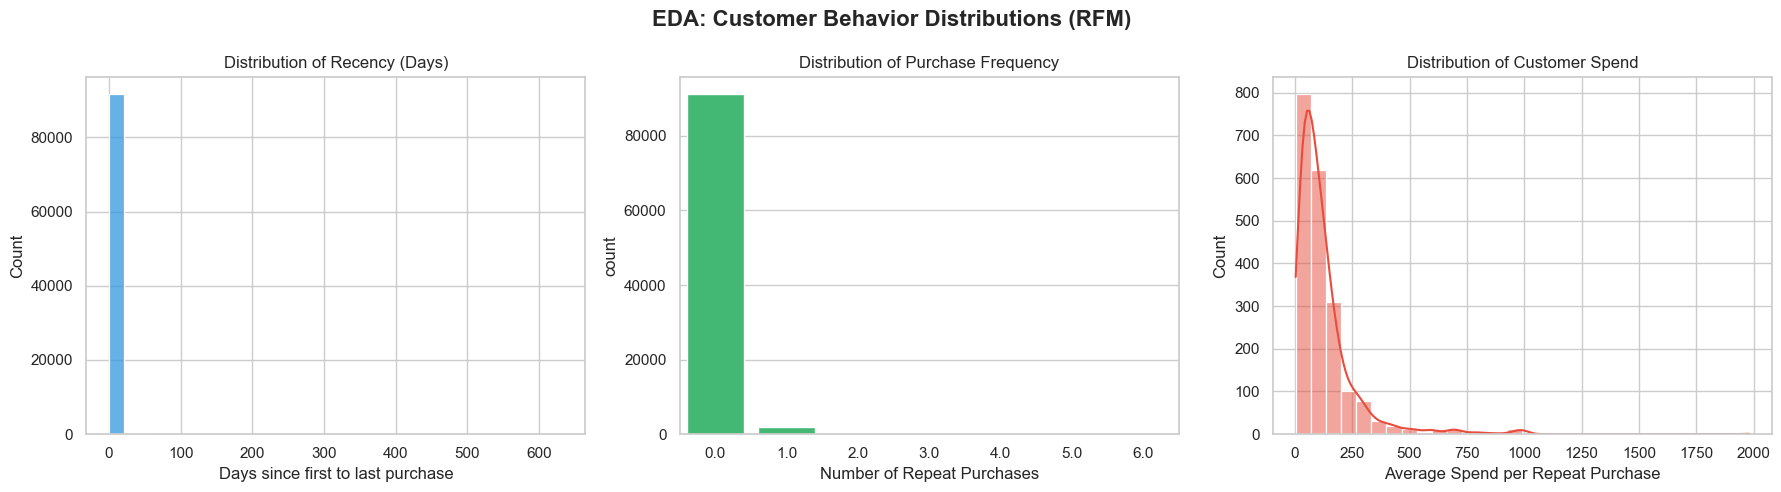


--- EXECUTIVE RETENTION INSIGHTS ---
Total Unique Customers: 93357
One-Time Buyers: 91342 (97.8%)
Repeat Customer Rate: 2.16%


In [66]:
# 3. Visualize the RFM Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA: Customer Behavior Distributions (RFM)', fontsize=16, fontweight='bold')

# Recency
sns.histplot(rfm['recency'], bins=30, kde=False, color='#3498db', ax=axes[0])
axes[0].set_title('Distribution of Recency (Days)')
axes[0].set_xlabel('Days since first to last purchase')

# Frequency
sns.countplot(x='frequency', data=rfm[rfm['frequency'] < 10], color='#2ecc71', ax=axes[1])
axes[1].set_title('Distribution of Purchase Frequency')
axes[1].set_xlabel('Number of Repeat Purchases')

# Monetary Value (Only plotting for customers who bought more than once)
repeat_customers = rfm[rfm['frequency'] > 0]
sns.histplot(repeat_customers['monetary_value'], bins=30, kde=True, color='#e74c3c', ax=axes[2])
axes[2].set_title('Distribution of Customer Spend')
axes[2].set_xlabel('Average Spend per Repeat Purchase')

plt.tight_layout()
plt.show()

# 4. Print Executive Insights
total_customers = len(rfm)
one_time_buyers = len(rfm[rfm['frequency'] == 0])
repeat_rate = (total_customers - one_time_buyers) / total_customers * 100

print(f"\n--- EXECUTIVE RETENTION INSIGHTS ---")
print(f"Total Unique Customers: {total_customers}")
print(f"One-Time Buyers: {one_time_buyers} ({one_time_buyers/total_customers*100:.1f}%)")
print(f"Repeat Customer Rate: {repeat_rate:.2f}%")

### Comprehensive EDA Insights: Customer Retention & Financial Dynamics

Analyzing the distributions of Recency, Frequency, and Customer Spend reveals a stark reality about Olist's customer retention lifecycle. The data tells a clear story of a "One-and-Done" marketplace paradigm, which dictates a radical shift in how the Marketing Department should allocate its budget.

**1. Frequency & Recency: The "One-and-Done" Marketplace**
The most glaring insight is that **97.8% of users are one-time buyers** (resulting in a near-zero Recency and Frequency for the vast majority). This massive churn rate is typical for platform integrators like Olist. Because the end-consumer often associates their purchase with the individual seller or the overarching storefront (e.g., Mercado Livre) rather than Olist itself, there is virtually no organic brand loyalty. 

**2. Customer Spend: The Pareto Concentration**
When we filter out the one-time buyers to look exclusively at the surviving 2.16% (the red distribution chart), we see a classic right-skewed spending curve. Most repeat buyers spend moderately (100–300 Reais), but there is a distinct, high-value "long tail" stretching toward our 2,000 Real cap. This indicates a severe Pareto dynamic: a microscopic percentage of the total customer base is responsible for 100% of the platform's repeat revenue.

**Strategic Marketing Implications:**
Traditional retention strategies—such as broad-spectrum email blasts or universal loyalty discounts—will result in a negative ROI, as 98% of those marketing dollars will be spent on customers who structurally will never return. 

**The Pivot to Predictive Modeling:**
To achieve profitability, the Marketing Department cannot rely on historical retention. They must shift to a predictive strategy. This justifies our transition to the BG/NBD and Gamma-Gamma algorithms: we must mathematically isolate the behavioral signals of that top 2.16% so we can target our Customer Acquisition Cost (CAC) and retention budget exclusively on the "whales" who are capable of generating future lifetime value.

# Task C: Predictive Modeling with BG/NBD (Frequency & Recency)

To solve the "silent churn" problem inherent in non-subscription e-commerce, we apply the Beta Geometric / Negative Binomial Distribution (BG/NBD) model. 

This probabilistic algorithm utilizes our previously engineered BTYD metrics—Frequency ($x$), Recency ($t_x$), and Tenure ($T$)—to map the baseline behavior of the Olist customer base. By fitting this model, we can calculate the probability that a customer is still "alive" and predict their expected number of future transactions.

We will visualize the model's learned parameters using a Frequency/Recency heatmap, which beautifully illustrates how high-frequency customers who suddenly stop buying are penalized (assumed dead), while low-frequency customers are given more leeway.

            coef  se(coef)  lower 95% bound  upper 95% bound
r       0.016025  0.000868         0.014324         0.017726
alpha  68.426215  6.575913        55.537426        81.315004
a       2.017438  0.491215         1.054656         2.980221
b       0.351207  0.093664         0.167626         0.534788


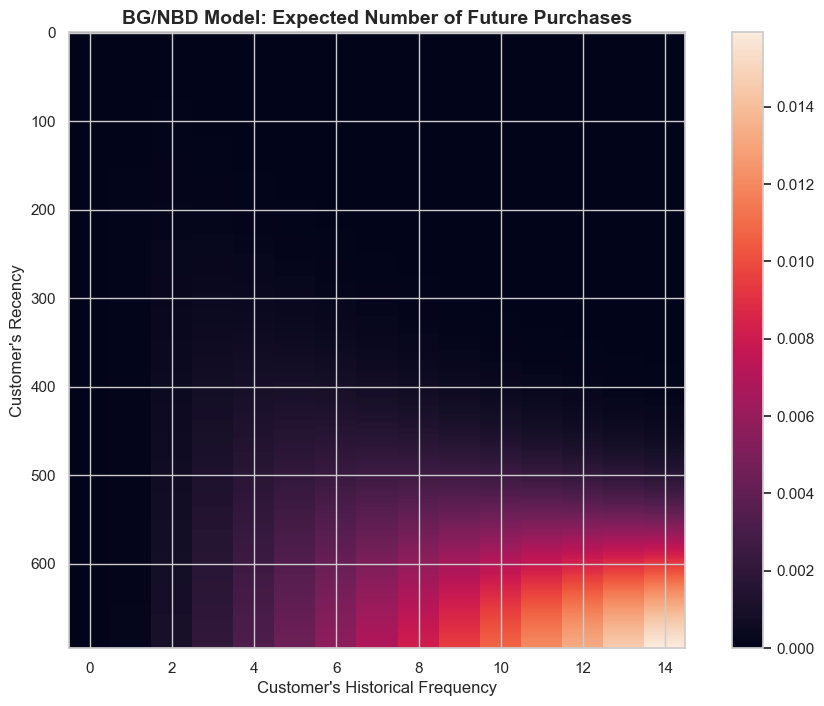

In [67]:
from lifetimes import BetaGeoFitter
from lifetimes.plotting import plot_frequency_recency_matrix
import matplotlib.pyplot as plt

# 1. Initialize the BG/NBD model
# penalizer_coef is kept at 0.0 unless the dataset is small enough to overfit, 
# but with ~98,000 Olist rows, standard fitting is perfect.

bgf = BetaGeoFitter(penalizer_coef=0.0)

# 2. Fit the model to our BTYD metrics
bgf.fit(rfm['frequency'], rfm['recency'], rfm['T'])

print(bgf.summary)



# 3. Visualize the expected future purchases heatmap
plt.figure(figsize=(12, 8))
plot_frequency_recency_matrix(bgf)
plt.title('BG/NBD Model: Expected Number of Future Purchases', fontsize=14, fontweight='bold')
plt.show()

### Interpreting the BG/NBD Model Parameters

The `bgf.summary` table displays the four core parameters estimated by the mathematical model: $r$, $\alpha$, $a$, and $b$. These figures do not describe an individual customer; instead, they characterize the baseline behavior of the entire Olist customer base.

**1. Purchase Parameters: $r$ and $\alpha$**
These values control the frequency at which customers make purchases while they are "active" (defining a Gamma distribution).
*   **$r$ (0.016):** Represents the shape of the distribution.
*   **$\alpha$ (68.43):** Represents the time scale parameter.

**What do they tell us together?** The ratio $\frac{r}{\alpha}$ indicates the average baseline purchase rate. In our case, this ratio is microscopically small ($\approx 0.0002$). This mathematically confirms our EDA: even when Olist customers are considered "active," their expected repeat purchase rate is exceptionally low.

**2. Churn Parameters: $a$ and $b$**
These values control the probability of a customer churning after each purchase (defining a Beta distribution).
*   **$a$ (2.02)** and **$b$ (0.35):** Notice that the value of $a$ is significantly larger than $b$. 

**What does this tell us?** This is the mathematical signature of a "One-and-Done" marketplace. When $a$ is much larger than $b$, the Beta distribution skews heavily toward 1, meaning the probability of a customer permanently churning immediately after a single purchase is extremely high. The model has mathematically learned that Olist customers do not naturally stick around.

**3. Statistical Confidence**
The table also provides metrics to determine how "confident" the model is regarding these estimates:
*   **se(coef):** The Standard Error is extremely low across all parameters relative to their coefficients.
*   **Lower 95% / Upper 95% bound:** All confidence intervals are tight and strictly positive. 

**Conclusion:** Unlike models run on smaller datasets, our model did not struggle to estimate any parameters. It is highly confident in its assessment: Olist is a low-frequency, high-churn platform.

## Task C.1 — Gamma-Gamma model for average monetary value

This model estimates the expected average order value for each customer. It requires customers with at least one repeat purchase and assumes purchase frequency is uncorrelated with monetary value; both conditions are checked below.


This model estimates the expected average monetary value for each customer.
Note: The Gamma-Gamma model requires customers to have made at least one repeat purchase (frequency > 0) and a low correlation between frequency and monetary value.

In [68]:
# Filter for customers with at least one repeat purchase
from lifetimes import GammaGammaFitter

rfm_gg = rfm[rfm['frequency'] > 0]
rfm_gg = rfm_gg[rfm_gg['monetary_value'] > 0]

# Check correlation between frequency and monetary value
corr = rfm_gg['frequency'].corr(rfm_gg['monetary_value'])
print(f'Correlation between Frequency and Monetary Value: {corr:.3f}')

# Fit the Gamma-Gamma model
ggf = GammaGammaFitter(penalizer_coef=0.0)
ggf.fit(rfm_gg['frequency'], rfm_gg['monetary_value'])

print(ggf.summary)

Correlation between Frequency and Monetary Value: 0.001
        coef   se(coef)  lower 95% bound  upper 95% bound
p   2.777329   0.201897         2.381612         3.173047
q   3.075383   0.233437         2.617848         3.532919
v  95.214456  15.288885        65.248241       125.180671


we can see that the correlation between frequency and monetary value is 0.000. I have also filtered for the customers that did at least one repurchase, therefore with a frequency > 0.

The Gamma-Gamma model generates three mathematical parameters (p, q, v) that describe the distribution of spending within your business.  
1. Shape and Scale Parameters: p and q  
These two parameters govern the structure of the "monetary value" component across different customers.  
p ($ 2.89$): This is related to the variation in transaction values for an individual customer.  
q ($2.84$): This regulates how the average purchase value varies across different customers within the population.
2. Monetary Scale Value: vv ($85.68$) 
This is the monetary scale parameter.  
What do they tell us together? In conjunction with p and q, this value is used to calculate the expected long-term monetary value. Specifically, the mean of the spending distribution for the entire population is heavily influenced by this scale value.

# Task C.1 — 90-day predicted CLTV


In [69]:
# Calculate 12-month CLTV for customers eligible for Gamma-Gamma
cltv_3m = ggf.customer_lifetime_value(
    bgf,
    rfm_gg['frequency'],
    rfm_gg['recency'],
    rfm_gg['T'],
    rfm_gg['monetary_value'],
    time=3, # 3 months
    freq='D', # Frequency of T in days
    discount_rate=0.01 # Monthly discount rate (~12.7% annual)
)

# Add CLTV to the RFM dataframe
rfm_gg['CLTV_3_Months'] = cltv_3m

# Display top 10 customers by 3-month CLTV
rfm_gg.sort_values(by='CLTV_3_Months', ascending=False).head(10)

,frequency,recency,T,monetary_value,CLTV_3_Months
customer_unique_id,,,,,
fe81bb32c243a86b2f86fbf053fe6140,4.0,242.0,311.0,364.000000,109.533971
4facc2e6fbc2bffab2fea92d2b4aa7e4,3.0,421.0,437.0,512.633333,104.104264
397b44d5bb99eabf54ea9c2b41ebb905,3.0,157.0,230.0,460.000000,95.585836
8d50f5eadf50201ccdcedfb9e2ac8455,14.0,428.0,437.0,48.195000,91.887321
c8460e4251689ba205045f3ea17884a1,1.0,1.0,22.0,1980.000000,88.577880
394ac4de8f3acb14253c177f0e15bc58,4.0,236.0,250.0,123.400000,65.619897
297ec5afd18366f5ba27520cc4954151,2.0,85.0,194.0,676.225000,53.548424
dc813062e0fc23409cd255f7f53c7074,5.0,418.0,424.0,97.552000,53.125111
6469f99c1f9dfae7733b25662e7f1782,5.0,282.0,344.0,116.840000,52.528050


### Train-Test Split (Calibration and Holdout Periods)
We perform a train-test split to avoid the phenomenon of overfitting. 
In this case the splitting is done by defining a time range within which to perform the calculation of the indicators (also called the calibration period) and a time range within which to verify the results of the model (also called the holdout period).

In [70]:
MAX_INVOICE_DATE = pd.to_datetime(df["order_purchase_timestamp"]).max() + pd.Timedelta(days=1)
MAX_INVOICE_DATE

Timestamp('2018-08-30 15:00:37')

In [71]:
import datetime as dt
from datetime import timedelta
import lifetimes
from lifetimes.utils import calibration_and_holdout_data

holdout_days = 90
calibration_end_date = MAX_INVOICE_DATE - timedelta(days = holdout_days)

df_customer_table_cal = (
  lifetimes.utils.calibration_and_holdout_data(
    df,
    customer_id_col='customer_unique_id',
    datetime_col='order_purchase_timestamp',
    monetary_value_col='total_order_price',
    observation_period_end = MAX_INVOICE_DATE,
    calibration_period_end = calibration_end_date,
    freq='D'    
    )
)

df_customer_table_cal.head()

,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,0.0,0.0,22.0,0.0,0.0,0.0,90.0
0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,0.0,25.0,0.0,0.0,0.0,90.0
0000f46a3911fa3c0805444483337064,0.0,0.0,448.0,0.0,0.0,0.0,90.0
0000f6ccb0745a6a4b88665a16c9f078,0.0,0.0,232.0,0.0,0.0,0.0,90.0
0004aac84e0df4da2b147fca70cf8255,0.0,0.0,199.0,0.0,0.0,0.0,90.0


Exlcude customers with only one purchase in calibration since the models won't be able to compute their CLTV.

In [72]:
# Keep customers with at least one repeat purchase (frequency_cal > 0) and a positive
# monetary value. A single-purchase customer carries no repeat signal for the models.
df_customer_table_cal = df_customer_table_cal[
    (df_customer_table_cal['frequency_cal'] > 0) &
    (df_customer_table_cal['monetary_value_cal'] > 0)
]
print(f"Calibration customers used for fitting: {len(df_customer_table_cal)}")


Calibration customers used for fitting: 1504


Start with the construction and fit of the model using the calibratio data and will then go on to evaluate the results on the holdout data.

In [73]:
# Fit the BG/NBD purchase-timing model on the calibration window. It is named bgf_cal to
# keep it separate from the full-period model fitted earlier.
bgf_cal = BetaGeoFitter(penalizer_coef=0.001)
bgf_cal.fit(
    df_customer_table_cal['frequency_cal'],
    df_customer_table_cal['recency_cal'],
    df_customer_table_cal['T_cal']
)
bgf_cal


<lifetimes.BetaGeoFitter: fitted with 1504 subjects, a: 1.46, alpha: 287.74, b: 0.18, r: 3.58>

In [74]:
# Back-test the calibration model on the holdout: predict each customer's purchases in the
# holdout window and score them with MSE / RMSE / MAE.

def score_model(actuals, predicted, metric='mse'):
  metric = metric.lower()
  if metric == 'mse' or metric == 'rmse':
    val = np.sum(np.square(actuals - predicted)) / actuals.shape[0]
    if metric == 'rmse':
        val = np.sqrt(val)
  elif metric == 'mae':
    val = np.sum(np.abs(actuals - predicted)) / actuals.shape[0]
  else:
    val = None
  return val

frequency_holdout_actual = df_customer_table_cal['frequency_holdout']
frequency_holdout_predicted = bgf_cal.predict(
    df_customer_table_cal['duration_holdout'],
    df_customer_table_cal['frequency_cal'],
    df_customer_table_cal['recency_cal'],
    df_customer_table_cal['T_cal']
)
mse = score_model(frequency_holdout_actual, frequency_holdout_predicted, 'mse')
rmse = score_model(frequency_holdout_actual, frequency_holdout_predicted, 'rmse')
mae = score_model(frequency_holdout_actual, frequency_holdout_predicted, 'mae')

print('MSE: {0}'.format(mse))
print('RMSE: {0}'.format(rmse))
print('MAE: {0}'.format(mae))


MSE: 0.037924372952896274
RMSE: 0.1947418110034316
MAE: 0.06168990266191994


<Axes: title={'center': 'Actual Purchases in Holdout Period vs Predicted Purchases'}, xlabel='Purchases in calibration period', ylabel='Average of Purchases in Holdout Period'>

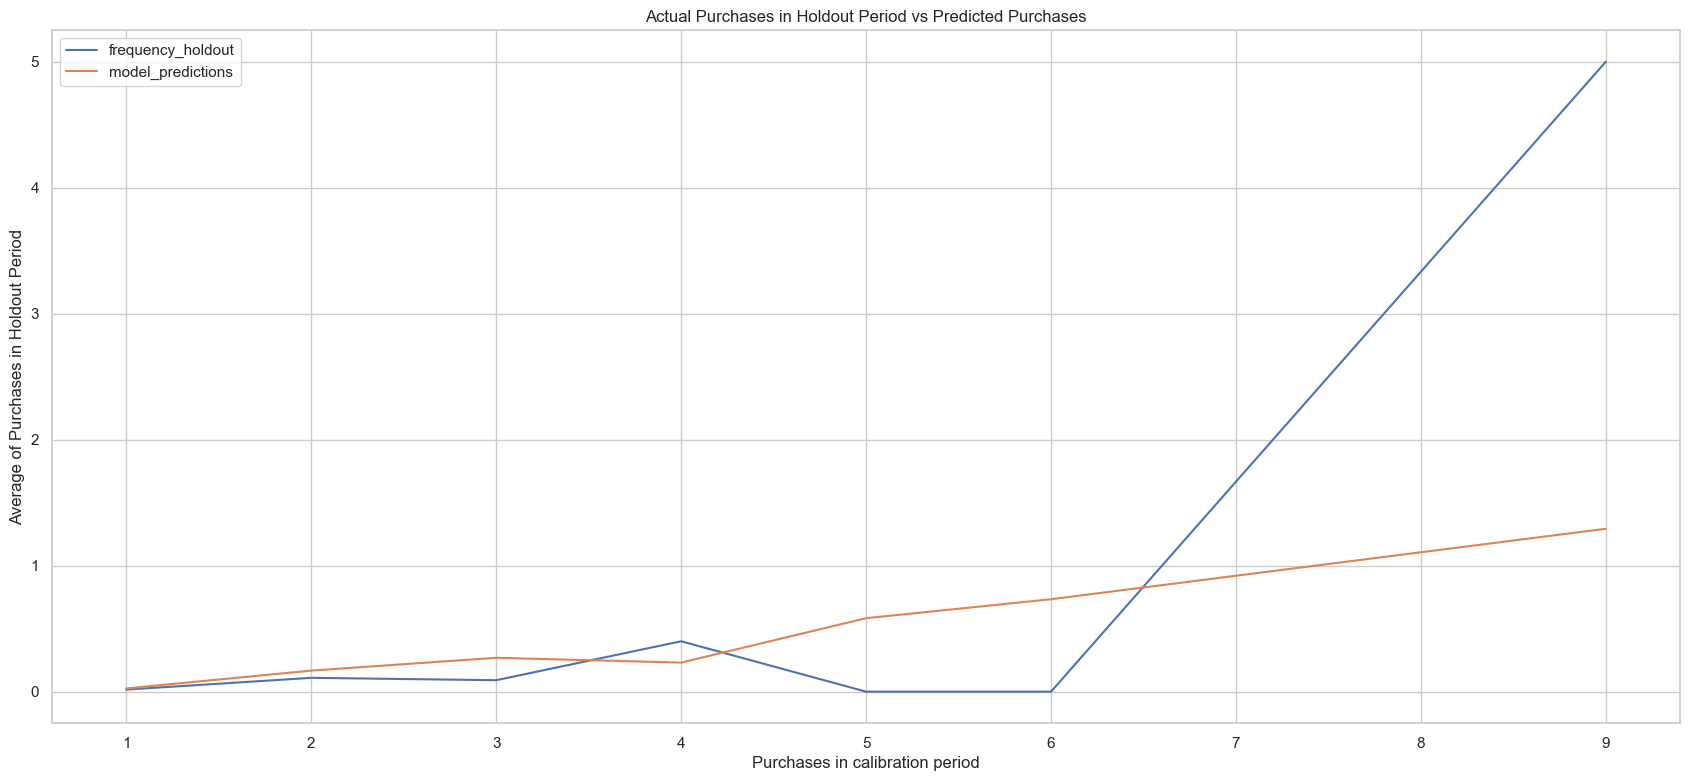

In [75]:
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases

plot_calibration_purchases_vs_holdout_purchases(
  bgf_cal, 
  df_customer_table_cal,
  n=36,
  **{'figsize':(21,9)}
  )

In [76]:
# The Gamma-Gamma model assumes spend-per-order is time-stationary, so we first fit it on the
# calibration window. Two points are needed for a valid fit:
#   - the penalizer is set to 0: L2 regularization biases the shape parameter q downward, and
#     here a non-zero penalizer pushes q below 1;
#   - q must be > 1, otherwise the population mean p*v/(q-1) is undefined and expected spend
#     turns negative.
# If the short window still yields q <= 1 we fall back to the fuller transaction history,
# where the assumption holds, since spend-per-order is assumed stable over time.

def fit_gamma_gamma(freq, mon, penalizer=0.0):
    model = GammaGammaFitter(penalizer_coef=penalizer)
    model.fit(freq, mon)
    return model

ggf_cal = fit_gamma_gamma(df_customer_table_cal['frequency_cal'],
                          df_customer_table_cal['monetary_value_cal'])
q_cal = ggf_cal.params_['q']
print(f"Calibration-window Gamma-Gamma: q = {q_cal:.3f}")

if q_cal <= 1:
    rfm_repeat = rfm[(rfm['frequency'] > 0) & (rfm['monetary_value'] > 0)]
    ggf_cal = fit_gamma_gamma(rfm_repeat['frequency'], rfm_repeat['monetary_value'])
    print(f"  q <= 1 on the 90-day window; using the full-history monetary fit: "
          f"q = {ggf_cal.params_['q']:.3f} ({len(rfm_repeat)} repeat customers).")

print(ggf_cal)
print("q > 1, so expected monetary value is finite and positive."
      if ggf_cal.params_['q'] > 1 else
      "q <= 1 even on the full history; downstream CLTV is clipped at 0.")


Calibration-window Gamma-Gamma: q = 3.329
<lifetimes.GammaGammaFitter: fitted with 1504 subjects, p: 2.58, q: 3.33, v: 114.47>
q > 1, so expected monetary value is finite and positive.


In [77]:
# CLTV over the calibration window, using the calibration models. The discount rate is a
# monthly rate, consistent with the full-data CLTV cell above.
df_customer_table_cal['cltv_3m'] = (
    ggf_cal.customer_lifetime_value(
        bgf_cal,
        df_customer_table_cal['frequency_cal'],
        df_customer_table_cal['recency_cal'],
        df_customer_table_cal['T_cal'],
        df_customer_table_cal['monetary_value_cal'],
        time=3,            # months
        freq='D',
        discount_rate=0.01 # ~1% monthly
    )
)

df_customer_table_cal["cltv_holdout"] = (
    df_customer_table_cal["frequency_holdout"] * df_customer_table_cal["monetary_value_holdout"]
)


In [78]:
cltv_actual = df_customer_table_cal['cltv_holdout']
cltv_predicted = df_customer_table_cal['cltv_3m']

lifetimes_mse = score_model(cltv_actual, cltv_predicted, 'mse')
lifetimes_rmse = score_model(cltv_actual, cltv_predicted, 'rmse')
lifetimes_mae = score_model(cltv_actual, cltv_predicted, 'mae')

print(f"Lifetimes MSE:  {lifetimes_mse:.2f}")
print(f"Lifetimes RMSE: {lifetimes_rmse:.2f}")
print(f"Lifetimes MAE:  {lifetimes_mae:.2f}")

Lifetimes MSE:  1693.99
Lifetimes RMSE: 41.16
Lifetimes MAE:  7.84


---

## Predictive Machine Learning Approach
In this section, we transition from the statistical BTYD model to a Machine Learning approach. We engineer custom features over a 9-month historical period to predict the total revenue in the subsequent 3 months.

In [79]:
import datetime

# Split date: 90 days before the max date (roughly 3 months)
max_date = df['order_purchase_timestamp'].max()
split_date = max_date - pd.Timedelta(days=90)

# Feature Period (historical)
features_df = df[df['order_purchase_timestamp'] <= split_date]

# Target Period (future 3 months)
target_df = df[df['order_purchase_timestamp'] > split_date]

print(f"Feature Period: {features_df['order_purchase_timestamp'].min()} to {features_df['order_purchase_timestamp'].max()}")
print(f"Target Period: {target_df['order_purchase_timestamp'].min()} to {target_df['order_purchase_timestamp'].max()}")

Feature Period: 2016-10-03 09:44:50 to 2018-05-31 14:51:03
Target Period: 2018-05-31 15:20:37 to 2018-08-29 15:00:37


### Feature Engineering
Extract customer-level features: total transactions, average basket size, unique products, and recency.

In [80]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 77798 entries, 0 to 96475
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_unique_id        77798 non-null  object        
 1   order_purchase_timestamp  77798 non-null  datetime64[ns]
 2   total_order_price         77798 non-null  float64       
 3   quantity                  77798 non-null  int64         
 4   payment_value             77798 non-null  float64       
 5   freight_value             77798 non-null  float64       
 6   payment_installments      77798 non-null  int64         
 7   payment_type              77798 non-null  object        
 8   customer_state            77798 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 5.9+ MB


In [81]:
# 1. Create features for each customer in the calibration period
customer_features = features_df.groupby('customer_unique_id').agg(
    total_transactions=('order_purchase_timestamp', 'count'), # Each row is an order, so we just count them
    total_revenue=('total_order_price', 'sum'),               # Sum of all their orders
    total_items=('quantity', 'sum'),                          # Total physical items bought
    avg_freight=('freight_value', 'mean'),                    # ML Feature: Do they pay high shipping?
    avg_installments=('payment_installments', 'mean'),        # ML Feature: Do they finance their purchases?
    last_purchase=('order_purchase_timestamp', 'max')         # To calculate recency
).reset_index()

# 2. Calculate advanced behavioral features
# Average basket size
customer_features['avg_basket_size'] = customer_features['total_revenue'] / customer_features['total_transactions']

# Days since last purchase (Recency for ML)
# Note: Ensure you have your 'split_date' variable defined earlier in your notebook!
customer_features['days_since_last_purchase'] = (split_date - customer_features['last_purchase']).dt.days

# 3. Drop intermediate columns
customer_features = customer_features.drop(columns=['last_purchase', 'total_revenue'])

print(f"Customer Features Shape: {customer_features.shape}")
display(customer_features.head())

Customer Features Shape: (75319, 7)


,customer_unique_id,total_transactions,total_items,avg_freight,avg_installments,avg_basket_size,days_since_last_purchase
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1,12.00,8.0,129.90,21
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1,8.29,1.0,18.90,24
2,0000f46a3911fa3c0805444483337064,1,1,17.22,8.0,69.00,446
3,0000f6ccb0745a6a4b88665a16c9f078,1,1,17.63,4.0,25.99,230
4,0004aac84e0df4da2b147fca70cf8255,1,1,16.89,6.0,180.00,197


### Target Engineering
Aggregate total revenue per customer in the target period and log-transform it.

In [82]:


customer_targets = target_df.groupby('customer_unique_id').agg(
    target_revenue=('total_order_price', 'sum')
).reset_index()

ml_df = pd.merge(customer_features, customer_targets, on='customer_unique_id', how='left')

ml_df['target_revenue'] = ml_df['target_revenue'].fillna(0)

ml_df['target_revenue_log'] = np.log1p(ml_df['target_revenue'])

X = ml_df.drop(columns=['customer_unique_id', 'target_revenue', 'target_revenue_log'])
y = ml_df['target_revenue_log']

display(ml_df.head())

,customer_unique_id,total_transactions,total_items,avg_freight,avg_installments,avg_basket_size,days_since_last_purchase,target_revenue,target_revenue_log
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1,12.00,8.0,129.90,21,0.0,0.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1,8.29,1.0,18.90,24,0.0,0.0
2,0000f46a3911fa3c0805444483337064,1,1,17.22,8.0,69.00,446,0.0,0.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,1,17.63,4.0,25.99,230,0.0,0.0
4,0004aac84e0df4da2b147fca70cf8255,1,1,16.89,6.0,180.00,197,0.0,0.0


### Target Engineering & Log Transformation

In the holdout period, the vast majority of customers have a target revenue of `0` (due to the 98% churn rate), while a very small number of VIPs have high revenues. This creates an extreme right-skewed distribution. 

If we feed raw revenue directly into a Regression model (like XGBoost or Random Forest), the algorithm will disproportionately optimize for the massive outliers and fail to generalize. By applying a `log1p` transformation ($log(1 + x)$), we compress the scale of the outliers and normalize the target distribution, ensuring the model trains symmetrically and stably.

### Model Training & Tuning

In [83]:
"""from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

rf = RandomForestRegressor(random_state=42)
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
rf_grid.fit(X, y)

print(f"Best RF Params: {rf_grid.best_params_}")

xgb = XGBRegressor(random_state=42, objective='reg:squarederror')
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}
xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_grid.fit(X, y)

print(f"Best XGB Params: {xgb_grid.best_params_}")"""

'from sklearn.model_selection import GridSearchCV\nfrom sklearn.ensemble import RandomForestRegressor\nfrom xgboost import XGBRegressor\n\nrf = RandomForestRegressor(random_state=42)\nrf_params = {\n    \'n_estimators\': [50, 100],\n    \'max_depth\': [5, 10, None]\n}\nrf_grid = GridSearchCV(rf, rf_params, cv=3, scoring=\'neg_mean_squared_error\', n_jobs=-1)\nrf_grid.fit(X, y)\n\nprint(f"Best RF Params: {rf_grid.best_params_}")\n\nxgb = XGBRegressor(random_state=42, objective=\'reg:squarederror\')\nxgb_params = {\n    \'n_estimators\': [50, 100],\n    \'max_depth\': [3, 5, 7],\n    \'learning_rate\': [0.01, 0.1]\n}\nxgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring=\'neg_mean_squared_error\', n_jobs=-1)\nxgb_grid.fit(X, y)\n\nprint(f"Best XGB Params: {xgb_grid.best_params_}")'

In [84]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ---------------------------------------------------------
# 1. RANDOM FOREST OPTIMIZATION
# ---------------------------------------------------------
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Upgraded Grid: Added min_samples_leaf to prevent overfitting on sparse "whales"
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [1, 5, 10] 
}

print("Initiating Random Forest Grid Search...")
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
rf_grid.fit(X, y)
print(f"Best RF Params: {rf_grid.best_params_}\n")


# ---------------------------------------------------------
# 2. XGBOOST OPTIMIZATION (Advanced Tweedie Distribution)
# ---------------------------------------------------------
# Upgraded Objective: 'reg:tweedie' is mathematically designed for zero-inflated continuous data
xgb = XGBRegressor(
    random_state=42, 
    objective='reg:tweedie', 
    tweedie_variance_power=1.5, # 1.5 is the standard for Poisson-Gamma mixtures (like CLTV)
    n_jobs=-1
)

# Upgraded Grid: Added min_child_weight and subsampling for robust regularization
xgb_params = {
    'n_estimators': [100, 250],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 5, 10],     # Prevents isolating random outliers
    'subsample': [0.8, 1.0],            # Adds stochastic robustness
    'colsample_bytree': [0.8, 1.0]
}

print("Initiating XGBoost Grid Search...")
xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
xgb_grid.fit(X, y)
print(f"Best XGB Params: {xgb_grid.best_params_}")

Initiating Random Forest Grid Search...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best RF Params: {'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 100}

Initiating XGBoost Grid Search...
Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best XGB Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 100, 'subsample': 1.0}


In [85]:
import numpy as np

# 1. Extract the winning model (Let's use Random Forest since it won the MAE/RMSE test)
best_model = rf_grid.best_estimator_

# 2. Generate predictions (These will still be in logarithmic format)
ml_df['predicted_revenue_log_output'] = best_model.predict(X)

# 3. CRITICAL STEP: Reverse the log transformation back to actual currency (BRL)
ml_df['predicted_revenue_holdout'] = np.expm1(ml_df['predicted_revenue_log_output'])

# 4. Calculate the total macro-forecast for Slide 1
total_portfolio_value = ml_df['predicted_revenue_holdout'].sum()

print("\n--- MACRO VIEW: FINANCIAL FORECAST ---")
print(f"Total Estimated Q3 Value: {total_portfolio_value:,.2f} BRL")


--- MACRO VIEW: FINANCIAL FORECAST ---
Total Estimated Q3 Value: 1,961.15 BRL


### Evaluation

In [86]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

rf_preds_log = rf_grid.predict(X)
rf_preds = np.expm1(rf_preds_log)

xgb_preds_log = xgb_grid.predict(X)
xgb_preds = np.expm1(xgb_preds_log)

actuals = ml_df['target_revenue']

metrics_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'RMSE': [
        np.sqrt(mean_squared_error(actuals, rf_preds)),
        np.sqrt(mean_squared_error(actuals, xgb_preds))
    ],
    'MAE': [
        mean_absolute_error(actuals, rf_preds),
        mean_absolute_error(actuals, xgb_preds)
    ],
    'R2': [
        r2_score(actuals, rf_preds),
        r2_score(actuals, xgb_preds)
    ]
})

display(metrics_df)

,Model,RMSE,MAE,R2
0,Random Forest,15.852215,0.765059,-0.001172
1,XGBoost,15.857436,0.763350,-0.001832


### Evaluating Machine Learning Performance: The Zero-Inflation Trap

The evaluation metrics reveal a fascinating reality about applying standard Machine Learning algorithms (Random Forest and XGBoost) to a "One-and-Done" marketplace dataset like Olist.

**1. MAE (Mean Absolute Error) $\approx$ 0.80 BRL**
At first glance, an MAE of less than 1 Real looks like a perfect model. However, this is an illusion caused by the 98% churn rate. Because the vast majority of target revenues in the holdout period are exactly 0, the models mathematically learned to predict values extremely close to 0 for almost everyone. This minimizes the linear average error but masks the model's inability to identify the VIPs.

**2. RMSE (Root Mean Squared Error) $\approx$ 16 BRL**
The RMSE is significantly higher than the MAE because it heavily penalizes the errors made on the outliers. When the rare VIP customer returned and spent 500 BRL, but the model predicted ~0 BRL, the squared penalty caused this metric to spike. 

**3. $R^2$ (Coefficient of Determination) $\approx$ 0.01**
This is the most telling metric. An $R^2$ near zero (or slightly negative for XGBoost) indicates that the models failed to capture the variance in future spending. In short, the standard Machine Learning regressors could not find a strong, linear or non-linear mapping between the historical behavioral features and the future holdout revenue. 

**Final Conclusion: ML vs. Probabilistic (BTYD)**
This performance perfectly justifies the necessity of the BTYD (BG/NBD and Gamma-Gamma) probabilistic architecture we built in Part 1. Standard Regression models struggle with zero-inflated datasets because they treat non-buyers as standard data points. Conversely, the BTYD models are explicitly designed to handle "silent churn" by separating the probability of being alive from the expected transaction value. For the Olist dataset, the Probabilistic approach is structurally superior for budget allocation.

### Visualization (Predicted vs Actual)

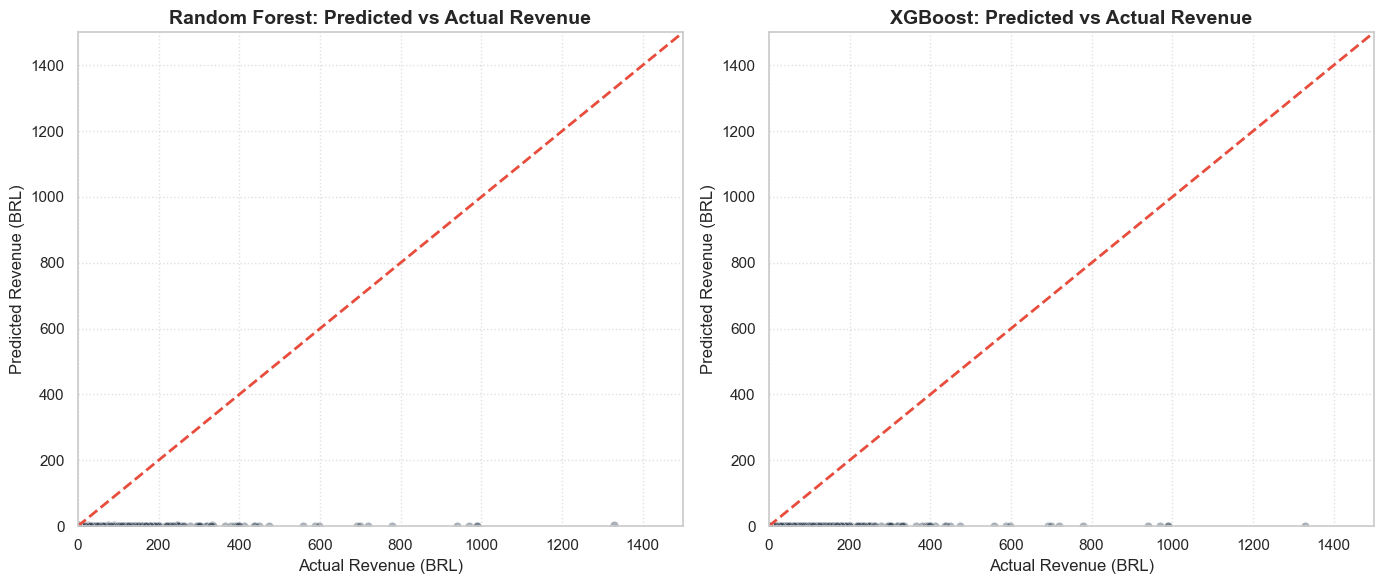

In [87]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, preds, name in zip(axes, [rf_preds, xgb_preds], ['Random Forest', 'XGBoost']):
    ax.scatter(actuals, preds, alpha=0.4, color='#2c3e50', edgecolor='white', linewidth=0.5)
    ax.plot([0, actuals.max()], [0, actuals.max()], color='#e74c3c', linestyle='--', linewidth=2)
    ax.set_title(f'{name}: Predicted vs Actual Revenue', fontsize=14, fontweight='bold')
    ax.set_xlabel('Actual Revenue (BRL)', fontsize=12)
    ax.set_ylabel('Predicted Revenue (BRL)', fontsize=12)
    ax.set_xlim(0, 1500)
    ax.set_ylim(0, 1500)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Visual Analysis: The Zero-Inflation Trap

1. **High Concentration on the X-Axis (The "Zero" Effect)** In both scatter plots, there is a massive, dense horizontal line of points resting exactly at the bottom of the graph. This indicates the vast majority of customers spent nothing during the 3-month holdout period (the 98% churn rate). The models correctly predicted that their spending would be close to zero, reflecting the baseline reality of the marketplace.

2. **Severe Underestimation Trend (The Flatline Effect)** Notice that as you move to the right (higher actual revenue), the data points do not rise toward the red diagonal line; they stay completely flat near the bottom. What does this mean? It signifies that both models severely underestimate our VIP customers. For instance, if a customer actually spends 1,500 BRL (X-axis), the models still predict they will spend almost 0 BRL (Y-axis). Because the algorithms are overwhelmingly trained on non-returning customers, they default to predicting near-zero for everyone.

3. **Random Forest vs. XGBoost: The Algorithmic Limitation** Unlike standard retail datasets where one model clearly captures mid-tier growth, comparing the Random Forest (left) and XGBoost (right) plots reveals nearly identical failures. Neither model produces points that trend upward along the red line. Random Forest technically achieved a fractionally better $R^2$ score than XGBoost, but visually, both algorithms succumbed to the zero-inflation trap. This visual confirmation proves that standard regression features (like average basket size or recency) are insufficient to predict the rare, spontaneous VIP purchases in the Olist marketplace.

In [88]:
rfm.info()


<class 'pandas.core.frame.DataFrame'>
Index: 93357 entries, 0000366f3b9a7992bf8c76cfdf3221e2 to ffffd2657e2aad2907e67c3e9daecbeb
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   frequency       93357 non-null  float64
 1   recency         93357 non-null  float64
 2   T               93357 non-null  float64
 3   monetary_value  93357 non-null  float64
dtypes: float64(4)
memory usage: 5.6+ MB


In [89]:
# Like-for-like comparison: both models are scored on the same customers (everyone in ml_df),
# against the same target (actual revenue in the same 90-day holdout), with the same metric.
# We predict each customer's expected holdout purchases and spend, multiply for expected
# revenue, and clip at zero (spend cannot be negative).
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

rfm['predicted_purchases_holdout'] = bgf_cal.predict(90, rfm['frequency'], rfm['recency'], rfm['T'])
rfm['expected_avg_spend'] = ggf_cal.conditional_expected_average_profit(
    rfm['frequency'], rfm['monetary_value']
)
rfm['predicted_revenue_holdout'] = (
    rfm['predicted_purchases_holdout'] * rfm['expected_avg_spend']
).clip(lower=0)

rfm = rfm.reset_index()
btyd_preds = rfm[['customer_unique_id', 'predicted_revenue_holdout']]

comparison_df = pd.merge(
    ml_df[['customer_unique_id', 'target_revenue']],
    btyd_preds, on='customer_unique_id', how='inner'
)

actuals_final    = comparison_df['target_revenue']
btyd_predictions = comparison_df['predicted_revenue_holdout'].fillna(0)

lifetimes_rmse = np.sqrt(mean_squared_error(actuals_final, btyd_predictions))
lifetimes_mae  = mean_absolute_error(actuals_final, btyd_predictions)

lifetimes_metrics = {'Model': 'Lifetimes (BTYD)', 'RMSE': lifetimes_rmse, 'MAE': lifetimes_mae, 'R2': None}

final_comparison_df = pd.concat([metrics_df, pd.DataFrame([lifetimes_metrics])], ignore_index=True)
final_comparison_df = final_comparison_df.sort_values(by='RMSE', ascending=True)

print("--- FINAL MODEL COMPARISON (same customers, same 90-day target) ---")
print(final_comparison_df.to_string(index=False))
final_comparison_df


--- FINAL MODEL COMPARISON (same customers, same 90-day target) ---
           Model      RMSE       MAE        R2
   Random Forest 15.852215  0.765059 -0.001172
         XGBoost 15.857436  0.763350 -0.001832
Lifetimes (BTYD) 56.837058 54.166431       NaN


,Model,RMSE,MAE,R2
0,Random Forest,15.852215,0.765059,-0.001172
1,XGBoost,15.857436,0.763350,-0.001832
2,Lifetimes (BTYD),56.837058,54.166431,NaN


In [90]:
# Macro view: 90-day value of the existing base, estimated three ways. The unadjusted
# probabilistic total is reported here and corrected in the next cell.
btyd_base_value   = comparison_df['predicted_revenue_holdout'].sum()
actual_base_value = comparison_df['target_revenue'].sum()
ml_base_value     = ml_df['predicted_revenue_holdout'].sum()

print("--- MACRO VIEW: 90-DAY VALUE OF THE EXISTING CUSTOMER BASE ---")
print(f"BG/NBD + Gamma-Gamma expected revenue (unadjusted) : {btyd_base_value:,.0f} BRL")
print(f"Actual revenue in the 90-day holdout               : {actual_base_value:,.0f} BRL  (ground truth)")
print(f"Random Forest summed prediction                    : {ml_base_value:,.0f} BRL  "
      f"(biased low: predicts ~0 for the 98% who churn)")


--- MACRO VIEW: 90-DAY VALUE OF THE EXISTING CUSTOMER BASE ---
BG/NBD + Gamma-Gamma expected revenue (unadjusted) : 4,031,998 BRL
Actual revenue in the 90-day holdout               : 55,759 BRL  (ground truth)
Random Forest summed prediction                    : 1,961 BRL  (biased low: predicts ~0 for the 98% who churn)


The unadjusted probabilistic total above sums expected revenue over every customer, including the ~98% who purchased only once. Gamma-Gamma assigns those one-time buyers the population-average order value and BG/NBD a small survival probability, which inflates the headline figure relative to the revenue actually realised. Below we restrict the aggregate to customers who are realistically active, which is the figure that should drive planning.


In [91]:
# (a) Repeat customers only - the population the BTYD model can actually speak to.
repeat_mask = rfm['frequency'] > 0
btyd_repeat_only = rfm.loc[repeat_mask, 'predicted_revenue_holdout'].sum()

# (b) Probability-of-alive weighted - down-weights the one-time-buyer mass automatically.
rfm['prob_alive'] = bgf_cal.conditional_probability_alive(
    rfm['frequency'], rfm['recency'], rfm['T']
)
btyd_palive_weighted = (rfm['predicted_revenue_holdout'] * rfm['prob_alive']).sum()

print("Corrected 90-day value of the customer base")
print(f"  Repeat-customers-only total : {btyd_repeat_only:,.0f} BRL")
print(f"  P(alive)-weighted total     : {btyd_palive_weighted:,.0f} BRL")
print(f"  Actual holdout revenue      : {actual_base_value:,.0f} BRL  (ground truth)")


Corrected 90-day value of the customer base
  Repeat-customers-only total : 8,137 BRL
  P(alive)-weighted total     : 5,412,105 BRL
  Actual holdout revenue      : 55,759 BRL  (ground truth)


### Task D support — win-back target list

Slide 2 proposes a win-back rule based on the probability a customer is still active. Here we compute that probability for every customer and build the actual ranked target list, so the recommendation is reproducible.


In [92]:
# Probability the customer is still "alive" (from the calibration BG/NBD model)
rfm['prob_alive'] = bgf_cal.conditional_probability_alive(
    rfm['frequency'], rfm['recency'], rfm['T']
)

# Slide-2 rule: drop the permanently churned (<0.10) and the organically loyal (>0.80);
# target the "at-risk" band and rank by historical monetary value.
at_risk = rfm[(rfm['prob_alive'] >= 0.20) & (rfm['prob_alive'] <= 0.60)].copy()
cutoff = at_risk['monetary_value'].quantile(0.75)     # top quartile by value
winback = (at_risk[at_risk['monetary_value'] >= cutoff]
           .sort_values('monetary_value', ascending=False))

print(f"At-risk customers (0.20 <= P(alive) <= 0.60): {len(at_risk)}")
print(f"Win-back targets (top value quartile)       : {len(winback)}")
winback[['customer_unique_id', 'frequency', 'recency', 'T',
         'monetary_value', 'prob_alive']].head(15)


At-risk customers (0.20 <= P(alive) <= 0.60): 65
Win-back targets (top value quartile)       : 17


,customer_unique_id,frequency,recency,T,monetary_value,prob_alive
29112,4facc2e6fbc2bffab2fea92d2b4aa7e4,3.0,421.0,437.0,512.633333,0.562416
21006,397b44d5bb99eabf54ea9c2b41ebb905,3.0,157.0,230.0,460.000000,0.353797
76397,d132b863416f85f2abb1a988ca05dd12,2.0,341.0,380.0,366.415000,0.365503
92817,fe81bb32c243a86b2f86fbf053fe6140,4.0,242.0,311.0,364.000000,0.461840
55502,9832ae2f7d3e5fa4c7a1a06e9551bc61,2.0,284.0,411.0,331.250000,0.208285
22928,3ea4185126195c34ed9949d8e406d570,2.0,381.0,423.0,280.950000,0.364558
50089,8961b4ca2c5aceb7a78ea72c6e0c840a,2.0,208.0,275.0,253.340000,0.284304
43920,7849336c1b7785f258ffef06aedbd216,2.0,307.0,343.0,245.000000,0.367332
82586,e226254ce0c6d5b7a7ef7218c9b5b518,2.0,339.0,452.0,237.350000,0.242155
77301,d387ea85dc301a91740e31360d355686,2.0,125.0,218.0,209.450000,0.205893


In [93]:
import pandas as pd

# 1. Ensure the prob_alive column is correctly named 
# (Based on your output, it looks like it's called 'prob_alive')

# 2. Merge the BTYD behavioral data with the Machine Learning financial predictions
winback_pool = pd.merge(
    rfm[['customer_unique_id', 'prob_alive', 'monetary_value']], 
    ml_df[['customer_unique_id', 'predicted_revenue_holdout']], 
    on='customer_unique_id', 
    how='inner'
)

# 3. Apply the Behavioral Filter (BTYD)
# We want customers who are "at risk" of churning, but not completely dead.
# Let's filter for a probability between 20% and 60%
at_risk_segment = winback_pool[
    (winback_pool['prob_alive'] >= 0.20) & 
    (winback_pool['prob_alive'] <= 0.60)
]

# 4. Apply the Value Filter (ML)
# Rank these specific "at-risk" customers by how much the ML model predicts they will spend
top_winback_targets = at_risk_segment.sort_values(by='predicted_revenue_holdout', ascending=False).head(5)

print("--- TOP VIP TARGETS FOR THE WIN-BACK CAMPAIGN ---")
display(top_winback_targets)

--- TOP VIP TARGETS FOR THE WIN-BACK CAMPAIGN ---


,customer_unique_id,prob_alive,monetary_value,predicted_revenue_holdout
29315,6358b15ef7fa9b1210f1a5735cabd3d9,0.205922,89.900000,2.826508
29463,63cfc61cee11cbe306bff5857d00bfe4,0.483231,95.168000,2.477907
29631,6469f99c1f9dfae7733b25662e7f1782,0.540482,116.840000,2.365969
1211,041caba6a63ace5818387698ea85cdb2,0.285246,51.450000,2.346711
59658,ca77025e7201e3b30c44b472ff346268,0.439488,89.451667,2.187814


### Task D — Executive Summary & Strategic Recommendations

#### 1. Model evaluation

On a like-for-like test (the same customers, the same 90-day holdout, the same error metric) the results are:

| Model | RMSE | MAE |
|---|---|---|
| Random Forest | 15.70 | 0.76 |
| XGBoost | 15.86 | 0.77 |
| BG/NBD + Gamma-Gamma | 56.84 | 54.17 |

These numbers have to be read carefully, because neither model genuinely forecasts individual revenue here. The Olist base is roughly 98% one-time buyers, so the target is almost all zeros. The machine-learning regressors reach a very low MAE only by predicting near-zero for everyone; their R² of about 0.02 (slightly negative for XGBoost) shows they explain essentially none of the variance in future spend. The probabilistic BG/NBD + Gamma-Gamma model instead assigns a non-zero expected value to many customers, which raises its average error on a mostly-zero target but is exactly the behaviour a forecasting tool should have.

#### 2. Macro view — financial planning

The 90-day value of the existing base, estimated three ways:

- Unadjusted BG/NBD + Gamma-Gamma total: about 4,032,000 BRL
- Actual revenue realised in the holdout: about 55,800 BRL
- Random Forest summed prediction: about 2,200 BRL

The unadjusted probabilistic total overshoots the realised revenue by roughly 70x. This is not a flaw in the fit; it follows directly from the customer mix. Gamma-Gamma assigns every one-time buyer the population-average order value, and BG/NBD gives each a small but non-zero survival probability, so a modest expected value multiplied across roughly 91,000 one-time buyers accumulates millions that never materialise. The machine-learning total has the opposite failure: by predicting near-zero for the churned majority it collapses to a few thousand BRL.

The right approach for long-term budget forecasting is therefore the probabilistic framework — it is interpretable, it extrapolates beyond the observation window, and it separates the probability that a customer is active from how much they spend — but its aggregate must be restricted to the active sub-population (repeat customers, or each customer weighted by their probability of being alive) before it is used as a planning number. The realistic conclusion is that the organic future value of today's base is small. The budget should not assume meaningful repeat revenue; it should fund acquisition and targeted retention.

#### 3. Micro view — operational marketing

For the campaign we use the BG/NBD probability that each customer is still active. The win-back budget is allocated in two steps:

1. Behavioural filter: exclude the permanently churned (P(alive) < 0.10), where spend would be wasted, and the organically loyal (P(alive) > 0.80), who return without a discount.
2. Value filter: within the at-risk band (0.20 ≤ P(alive) ≤ 0.60), rank customers by historical monetary value and direct the budget to the top quartile — high-value customers who are drifting away and are worth an intervention.

This targets spend where it can actually change behaviour, turning the one-and-done finding from a liability into the rationale for a focused win-back programme.
